# Heart Project

### Importing Libraries

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler


### Ignoring Warnings

In [178]:
warnings.filterwarnings("ignore")

### Loading of Dataset

In [179]:
data = pd.read_csv('heart.csv')

### EDA & Cleaning

In [180]:
data.head()



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [181]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [182]:
data.shape

(918, 12)

In [183]:
data.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [184]:
data.isnull().sum()
# No null Values


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [185]:
data.duplicated().sum()
# No Duplicated Values

np.int64(0)

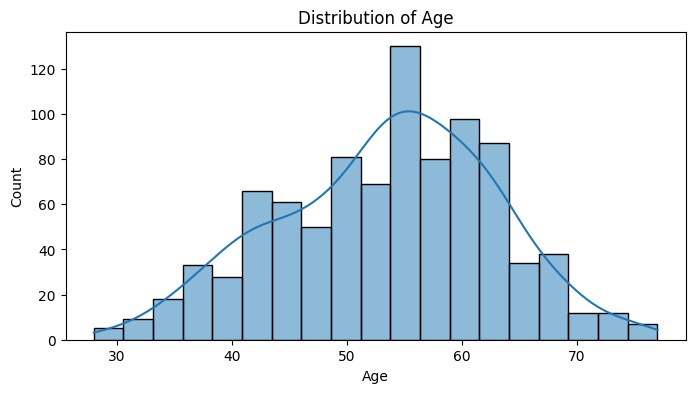

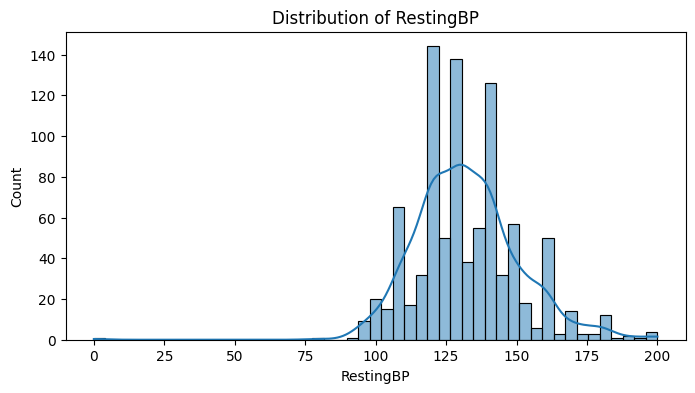

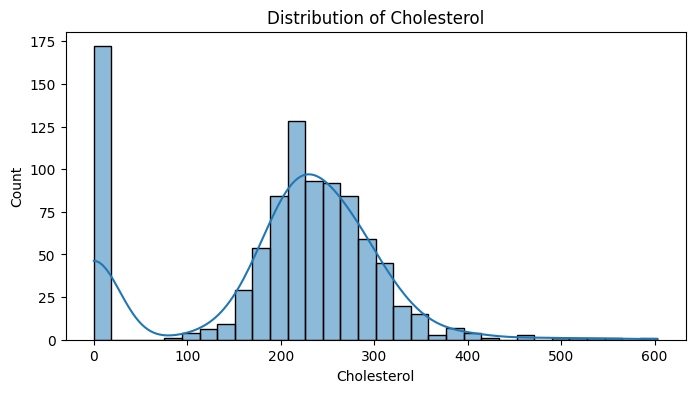

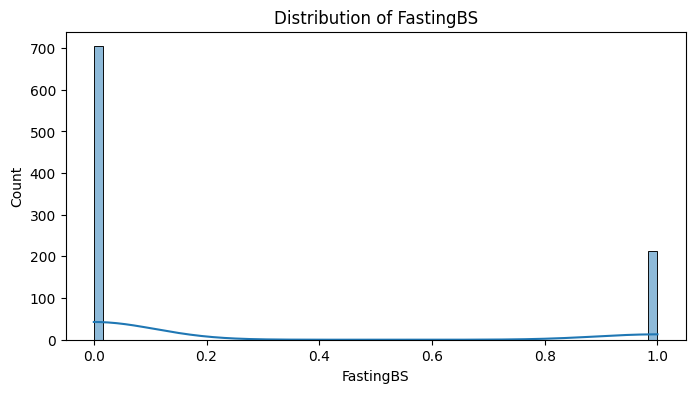

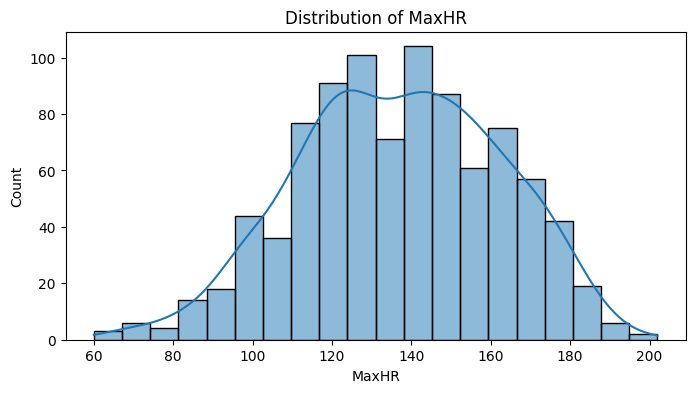

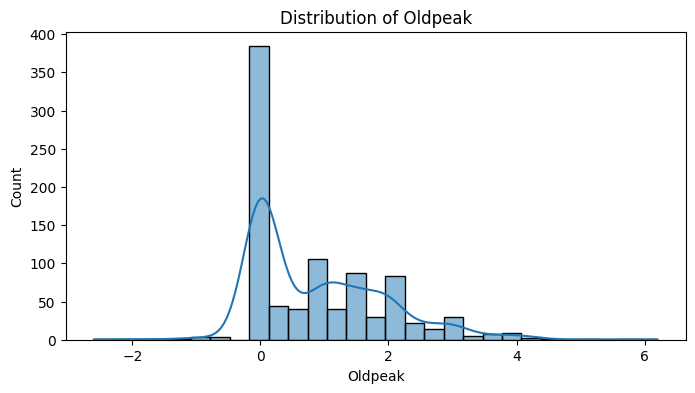

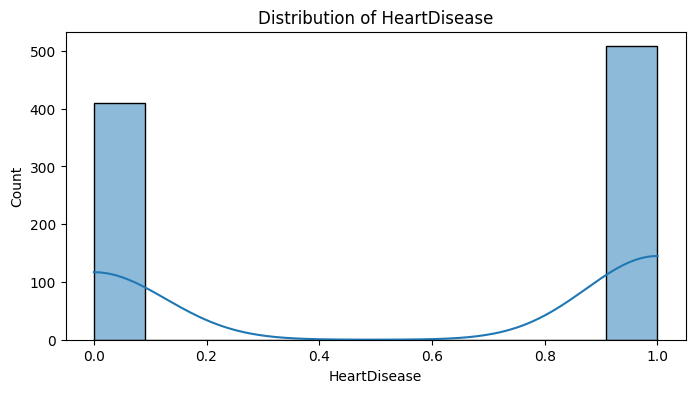

In [187]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()
for i in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

### NOTES
##### 1. A Person can't have 0 Resting BP 
##### 2. A Person can't have 0 Cholesterol 

<Axes: xlabel='Cholesterol', ylabel='Count'>

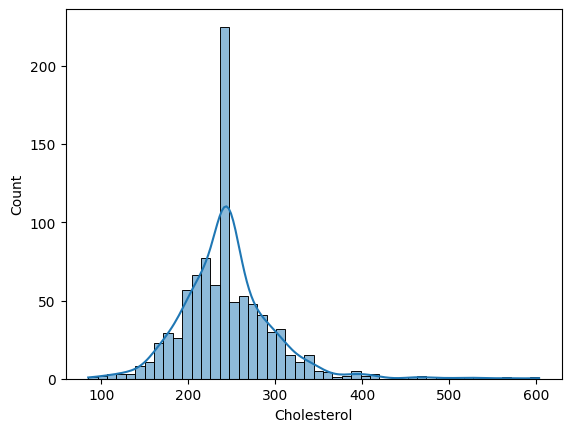

In [188]:
pd.set_option('display.max_rows', None)

chol_mean = data['Cholesterol'][data['Cholesterol'] != 0].mean()

data['Cholesterol'] = data['Cholesterol'].replace(0, chol_mean)

sns.histplot(data['Cholesterol'], kde=True)

<Axes: xlabel='RestingBP', ylabel='Count'>

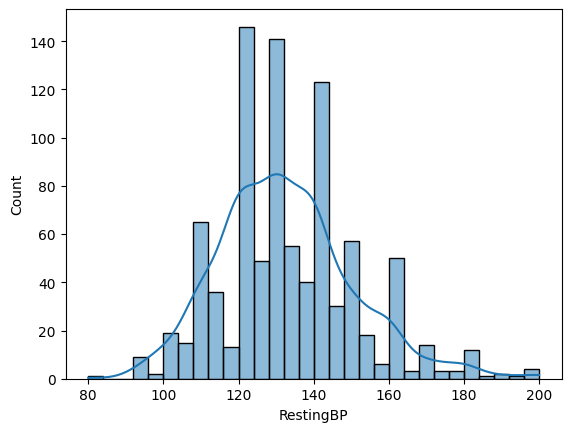

In [189]:
pd.set_option('display.max_rows', None)
chol_mean = data['RestingBP'][data['RestingBP'] != 0].mean()
data['RestingBP'] = data['RestingBP'].replace(0, chol_mean)
sns.histplot(data['RestingBP'], kde=True)

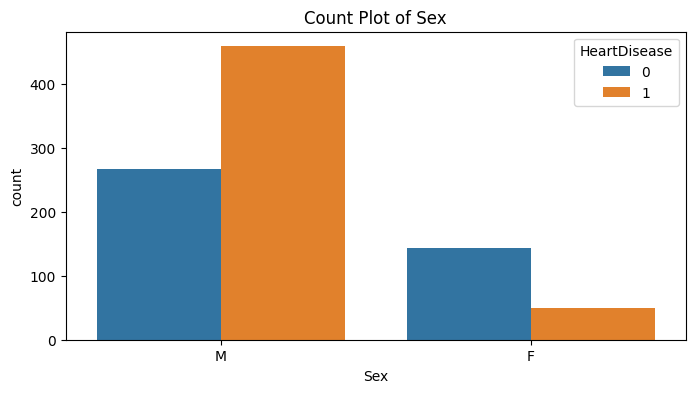

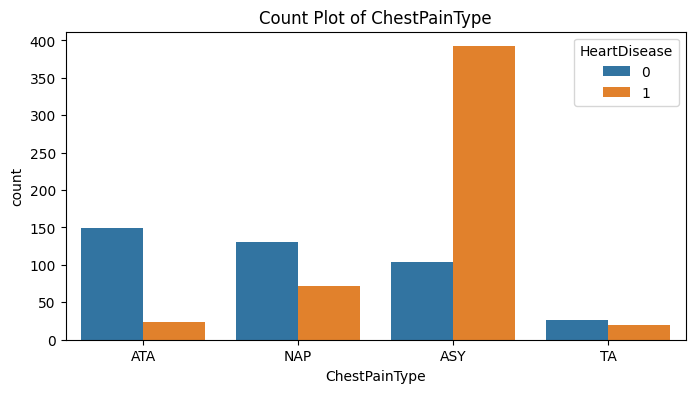

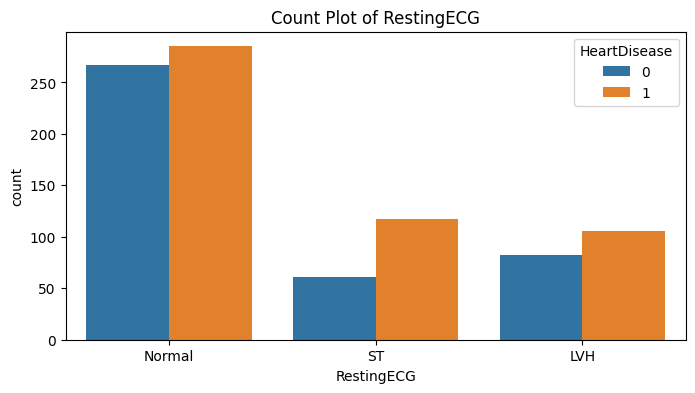

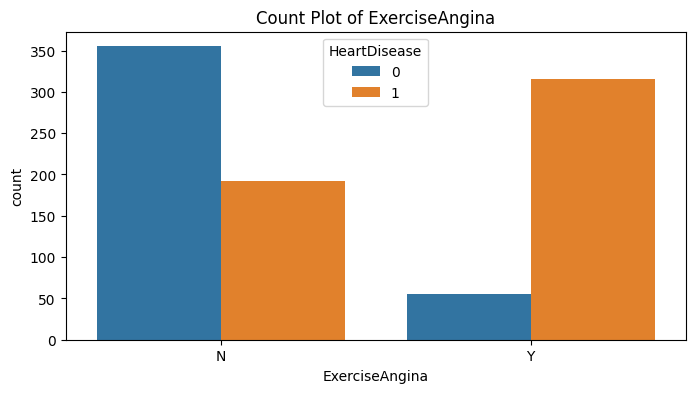

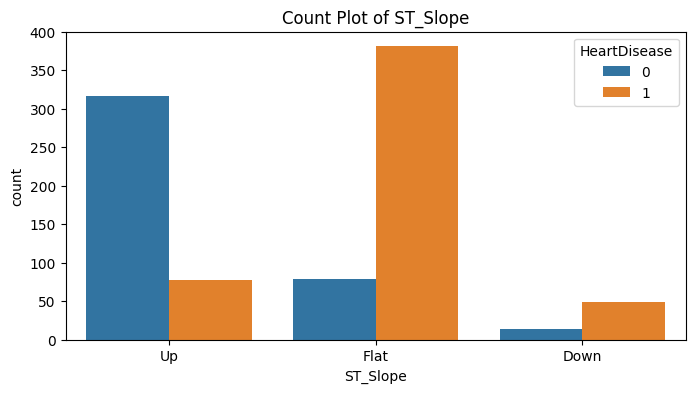

In [190]:
for i in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=data[i],hue=data['HeartDisease'])
    plt.title(f'Count Plot of {i}')
    plt.show()

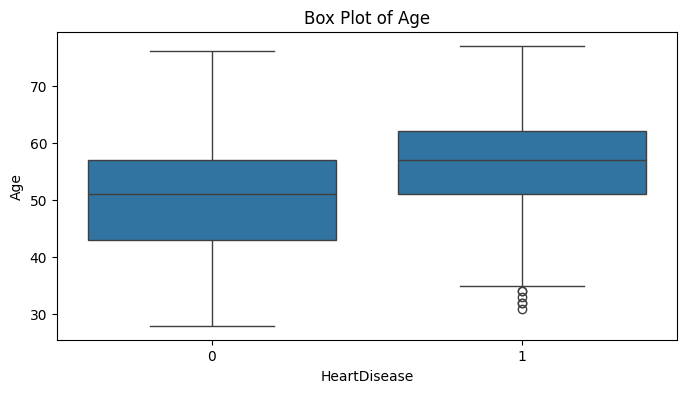

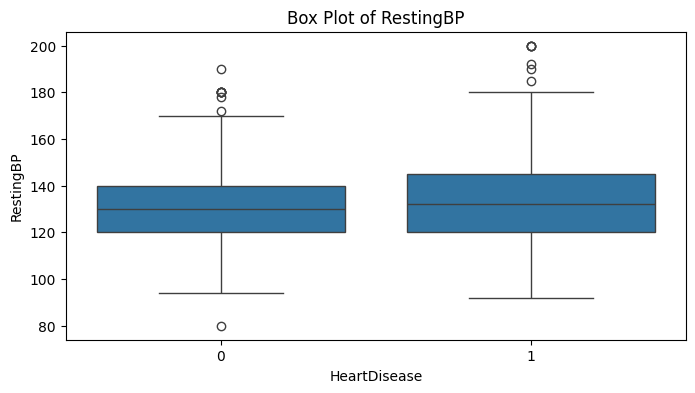

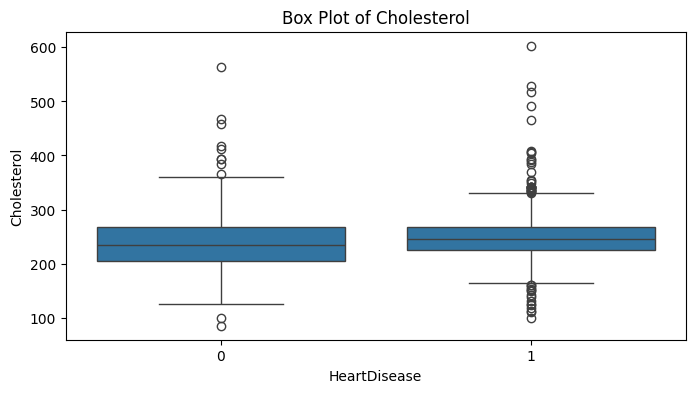

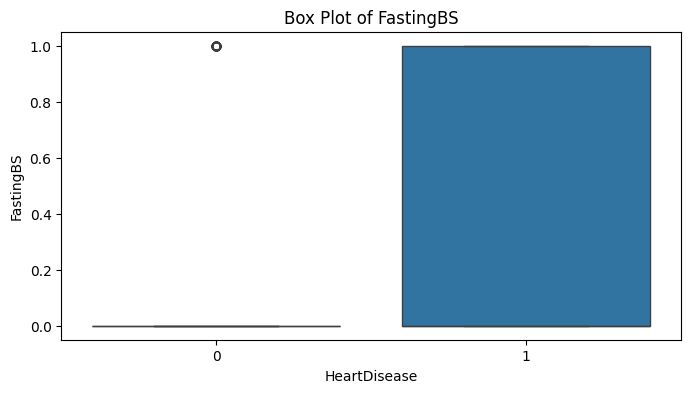

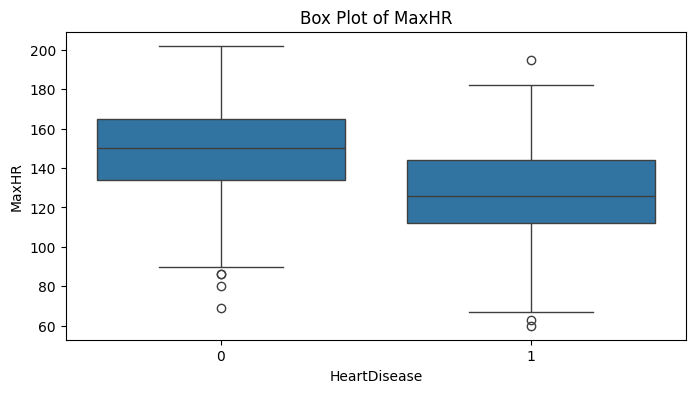

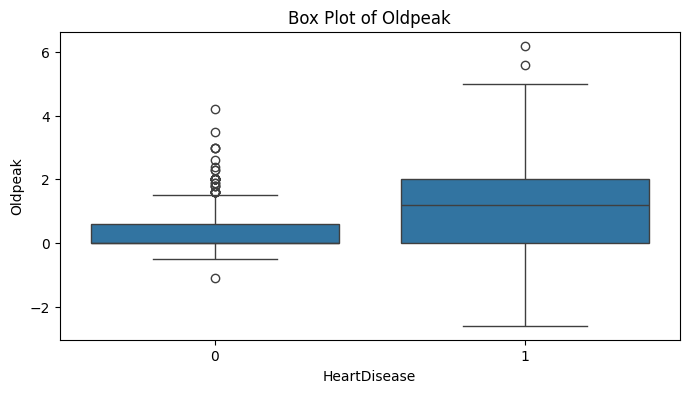

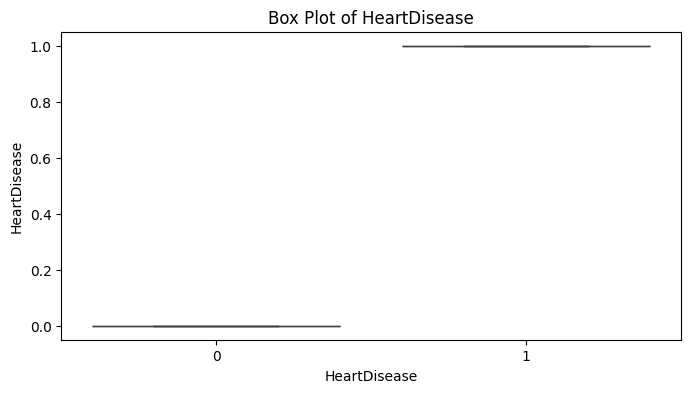

In [191]:
for i in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=data[i],x=data['HeartDisease'])
    plt.title(f'Box Plot of {i}')
    plt.show()

<Axes: >

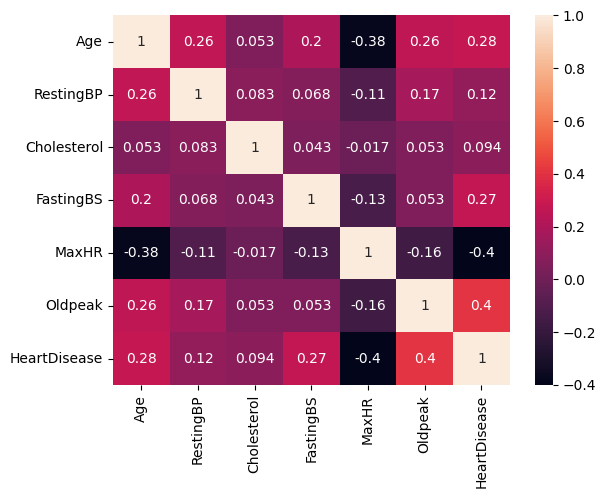

In [193]:
sns.heatmap(data.corr(numeric_only=True), annot=True)

### Data Preprocessing and cleaning

In [199]:
df_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [200]:
df_encoded.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
5,39,120,339,0,170,0,0,1,0,1,0,1,0,0,0,1
6,45,130,237,0,170,0,0,0,1,0,0,1,0,0,0,1
7,54,110,208,0,142,0,0,1,1,0,0,1,0,0,0,1
8,37,140,207,0,130,1,1,1,0,0,0,1,0,1,1,0
9,48,120,284,0,120,0,0,0,1,0,0,1,0,0,0,1


In [201]:
cols = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
scaler = StandardScaler()
df_encoded[cols] = scaler.fit_transform(df_encoded[cols])
display(df_encoded.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True
